<a href="https://colab.research.google.com/github/blancaorozco/analysis-ever-pick/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()
plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.
En la tabla de users las columnas churn_date y city presentan el 88% y 11% de valores nulos. Las columnas reg_date y churn_date estan en formato object en vez de fecha. En la tabla usage las columnas length y duration presenatan 44% y 55% de valores nulos mientras que la columna date tiene un minimo de nulos. Ademas la columna date esrá en formato objet y en vez de fecha. Hay que investigar en las columnas con porcentajes del 44 al 55 para detrminar si imputamos o los dejamos nulos, en churn_date veremos si se ignoran pues puedes significar que los clientes aun conseran su plan. En la columna city debemos investicar para imputar.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  

 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  

 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
   churn_date 88%,
   city 11%,
   length 44%,
   duration 55%,
   date 0.10%           
- Indica qué harías: ¿imputar, eliminar, ignorar?
 churn_date: ignorar,
 city: imputar,
 length y duration: ignorar,
 date: ignorar


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users[['user_id', 'age']]

,user_id,age
0,10000,38
1,10001,53
2,10002,57
3,10003,69
4,10004,63
...,...,...
3995,13995,60
3996,13996,24
3997,13997,58
3998,13998,57


- La columna `user_id`no tiene nulos y deberia estar en ormato object
- La columna `age` presenta un valor atipico como -999

In [ ]:
users['age'].describe()

count    4000.000000
mean       33.739750
std       123.232257
min      -999.000000
25%        32.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64























































































































































































































































































































































































































































































































































- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas no presentan valores atípicos, ni nulos

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[['city', 'plan']]

,city,plan
0,Medellín,Basico
1,?,Basico
2,CDMX,Basico
3,Bogotá,Premium
4,GDL,Basico
...,...,...
3995,Medellín,Basico
3996,Medellín,Premium
3997,Bogotá,Premium
3998,Bogotá,Basico


- La columna `city` presenta algun caracter atipico
- La columna `plan`presenta 2 tipos de servicios, básico y premium.

In [ ]:
# explorar columna categórica de usage
usage['type']

0        call
1        text
2        text
3        call
4        call
         ... 
39995    call
39996    call
39997    call
39998    text
39999    call
Name: type, Length: 40000, dtype: object

- La columna `type`muestra 0 nulos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.


**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  en la columna city y age
- ¿Qué acción tomarías?
  En age reemplazarlos por la edad promedio
  En city eliminarlo

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors= 'coerce')
users['reg_date']


0      2022-01-01 00:00:00.000000000
1      2022-01-01 06:34:17.914478619
2      2022-01-01 13:08:35.828957239
3      2022-01-01 19:42:53.743435858
4      2022-01-02 02:17:11.657914478
                    ...             
3995   2024-12-29 21:42:48.342085520
3996   2024-12-30 04:17:06.256564144
3997   2024-12-30 10:51:24.171042768
3998   2024-12-30 17:25:42.085521392
3999   2024-12-31 00:00:00.000000000
Name: reg_date, Length: 4000, dtype: datetime64[ns]

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors= 'coerce')
usage['date']

0       2024-01-01 00:00:00.000000000
1       2024-01-01 00:06:30.969774244
2       2024-01-01 00:13:01.939548488
3       2024-01-01 00:19:32.909322733
4       2024-01-01 00:26:03.879096977
                     ...             
39995   2024-06-29 23:33:56.120903022
39996   2024-06-29 23:40:27.090677266
39997   2024-06-29 23:46:58.060451510
39998   2024-06-29 23:53:29.030225754
39999   2024-06-30 00:00:00.000000000
Name: date, Length: 40000, dtype: datetime64[ns]

In [ ]:


# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, el año 2026 tiene menos registros, posiblemente porque solo se cuenta el priemer mes, y falta el año 2025


In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solo aparece el año 2024 y un conteo inusual del mismo, extremadamente elevado.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:
En la tabla usege solo cuanta con el año 2024, mientras que en la tabla users maneja del 2022 al 2026, omitiendo el año 2025.
**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Si, solo el año 2026.
- ¿Qué harías con ellas?
 Eliminar el año 2026 para trabajar con los años donde tenemos la mayor cantidad de datos.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] =  users['city'].replace('?', pd.NA)

# Verificar cambios
users['city']

0       Medellín
1           <NA>
2           CDMX
3         Bogotá
4            GDL
          ...   
3995    Medellín
3996    Medellín
3997      Bogotá
3998      Bogotá
3999      Bogotá
Name: city, Length: 4000, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:

# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
No hay problema ya que en duracion solo aplica cuando es llamada y no texto y en la columna length tambien es normal porque solo mide la cantidad de mensage en texto, por lo tanto si se trata de una llamada habrá un nulo.


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas
usage['min_call'] = usage['duration'].fillna(0)


# Agrupar información por usuario
usage_agg = usage.groupby('user_id')[['is_text', 'is_call', 'min_call']].sum().reset_index()


# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,min_call
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg =  usage_agg.rename(columns={'is_text' :"cant_mensajes", "is_call" : "cant_llamadas", "min_call": "cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on= 'user_id' )
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes','cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.138285,5.524381,4.478120,23.317054
std,17.691541,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

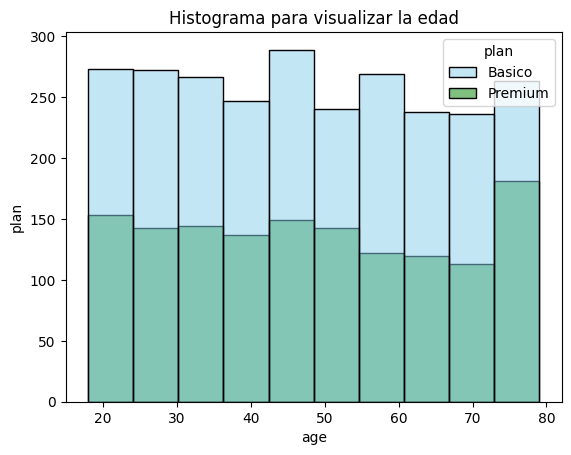

In [ ]:

# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', bins=10, binrange=(18, 79), hue='plan', palette=['skyblue','green'], edgecolor='black')
plt.title('Histograma para visualizar la edad')
plt.ylabel('plan')
plt.show()

💡Insights:
- Distribución simétrica, clientes de 40 a 50 son los que mayormente adquieren un plan, los adultos mayoes de mas de 70 años prefieren el plan básico

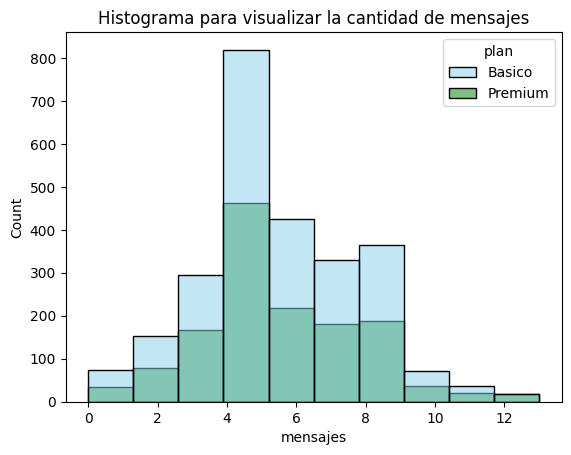

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', bins=10, binrange=(0,13), hue='plan', palette=['skyblue','green'], edgecolor='black')
plt.title('Histograma para visualizar la cantidad de mensajes')
plt.xlabel('mensajes')
plt.show()

💡Insights:
Distribución ligeramente sesgada a la derecha, no hay diferencia en la cantidad de mensajes entre usuarios Básico y Premium

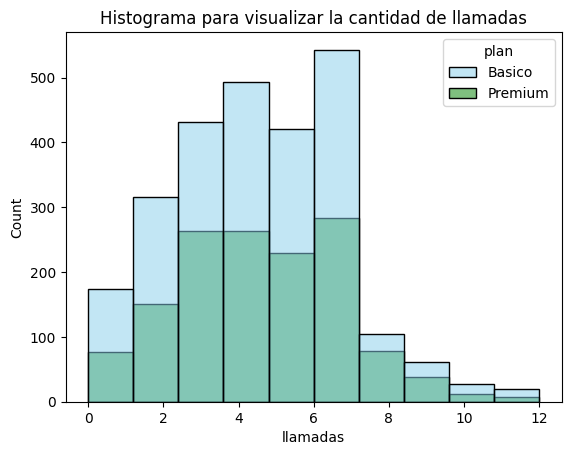

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', bins=10, binrange=(0,12), hue='plan', palette=['skyblue','green'], edgecolor='black')
plt.title('Histograma para visualizar la cantidad de llamadas')
plt.xlabel('llamadas')
plt.show()

💡Insights:
- Distribución sesgada a la derecha,

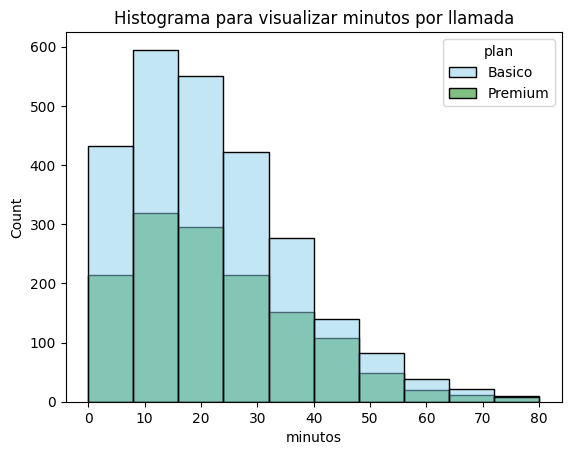

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', bins=10, binrange=(0,80), hue='plan', palette=['skyblue','green'], edgecolor='black')
plt.title('Histograma para visualizar minutos por llamada')
plt.xlabel('minutos')
plt.show()

💡Insights:
Distribución sesgada a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

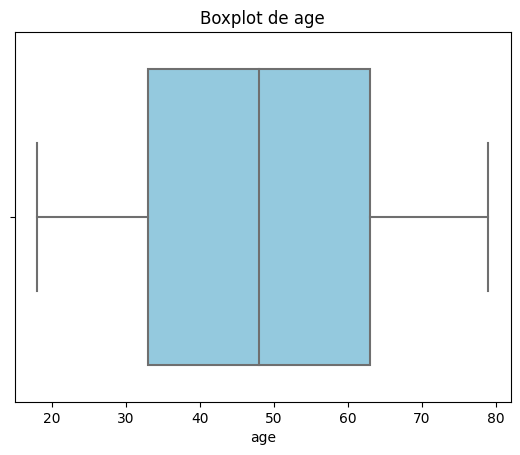

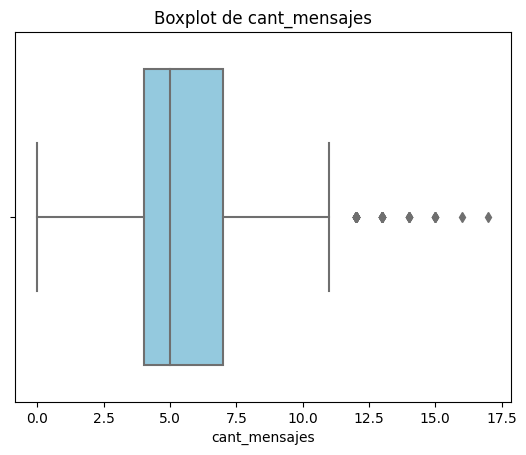

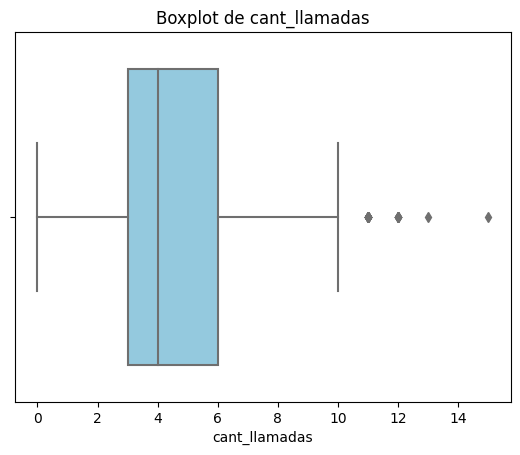

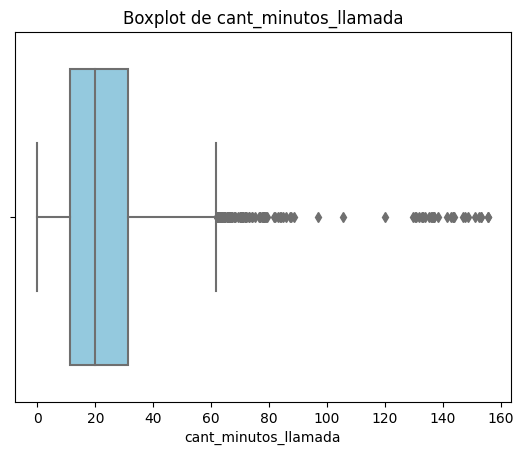

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col], color='skyblue')
    plt.title(f'Boxplot de {col}')
    plt.xlabel(col)
    plt.show()


💡Insights:
- Age: no presenta outliers
- cant_mensajes: presenta outliers
- cant_llamadas: presenta outliers
- cant_minutos_llamada: presenta outliers

In [ ]:
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    print(col, ' :', 'q1 | ', q1, '| q3 |', q3)

cant_mensajes  : q1 |  4.0 | q3 | 7.0
cant_llamadas  : q1 |  3.0 | q3 | 6.0
cant_minutos_llamada  : q1 |  11.12 | q3 | 31.415


In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)

    IQR = q3 - q1
    upper = q3 + 1.5 * IQR
    print('limite superior de', col,':', upper)

limite superior de cant_mensajes : 11.5
limite superior de cant_llamadas : 10.5
limite superior de cant_minutos_llamada : 61.8575


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()


,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener o no outliers, porqué? Mantener porque es un comportamiento que se puede dar aunque se salga de la media.
- cant_llamadas: mantener o no outliers, porqué? Mantener porque no es un error, se puede dar.
- cant_minutos_llamada: mantener o no outliers, porqué? Mantener porque habalar por telefono por casi 2 hr se da con facilidad.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:

# Crear columna grupo_uso

def crearg_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5 :
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'
user_profile['grupo_uso'] = user_profile.apply(crearg_uso, axis=1)


In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(fila):
    if fila['age'] < 30:
        return 'Joven'
    elif fila['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'
user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

#cambiar columna edad a entero...
user_profile['age'] = user_profile['age'].astype(int)



In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


In [ ]:
pd.crosstab(user_profile['grupo_edad'], user_profile['grupo_uso'])


grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,153,364,1500
Adulto Mayor,74,257,891
Joven,51,157,552


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

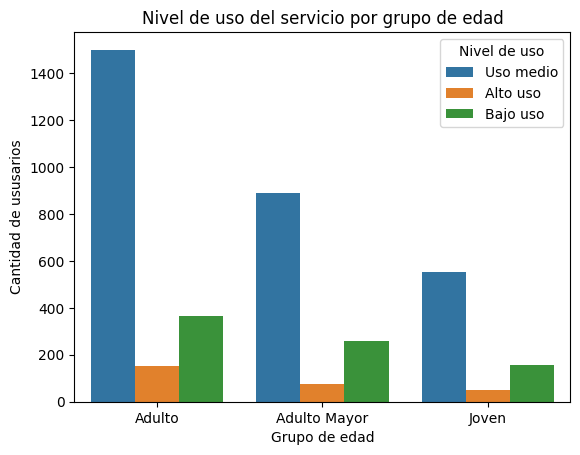

In [ ]:
sns.countplot(data=user_profile, x='grupo_edad', hue='grupo_uso')
plt.title('Nivel de uso del servicio por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de ususarios')
plt.legend(title='Nivel de uso')
plt.show()

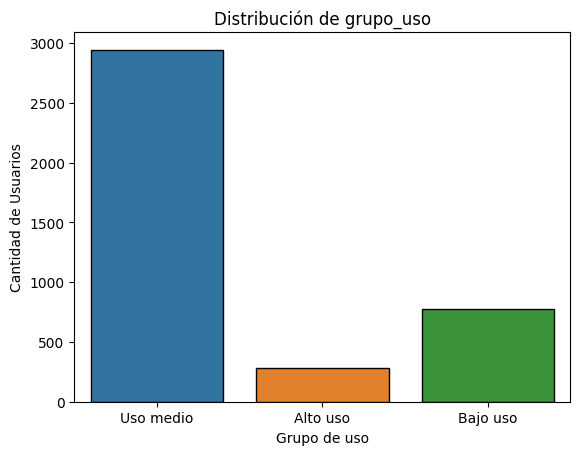

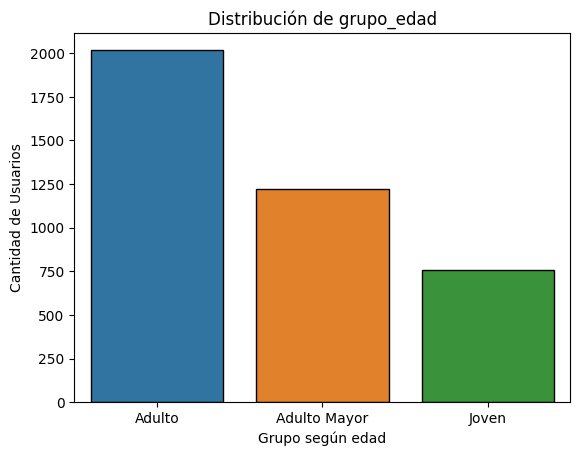

In [ ]:

# Visualización de los segmentos por uso y por edad
grupos = ['grupo_uso', 'grupo_edad']
etiquetax = ['Grupo de uso', 'Grupo según edad']
for var, x in zip(grupos, etiquetax):
    sns.countplot(data=user_profile, x= var, edgecolor='black')
    plt.title(f'Distribución de {var}')
    plt.xlabel(x)
    plt.ylabel('Cantidad de Usuarios')
    plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?
- ¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

A continuación se presenta una versión redactada con un enfoque ejecutivo, resaltando los principales hallazgos y las recomendaciones de negocio.

**Insight Ejecutivo para Stakeholders**

El proceso de preparación de datos identificó problemas de calidad que podían afectar la confiabilidad del análisis. Se detectaron formatos incorrectos en fechas, edades con valores atípicos, caracteres inválidos ("?") en la columna city y valores nulos en varias variables. Los porcentajes de datos faltantes fueron: churn_date (88%), duration (55%), length (44%), city (11%) y date (0.10%). Tras el proceso de limpieza y validación, el conjunto de datos quedó preparado para un análisis consistente.

El análisis de segmentación muestra que los adultos constituyen el grupo de clientes más importante para ConnectaTel, con 2,017 usuarios, de los cuales aproximadamente el 74% pertenece al segmento de uso medio y 153 clientes presentan un uso alto. Los adultos mayores representan el segundo segmento más numeroso (1,222 clientes), también dominado por usuarios de uso medio (73%), aunque con una mayor proporción de clientes de bajo uso. Por su parte, los jóvenes conforman el grupo más pequeño (760 clientes) y, aunque predominan igualmente los usuarios de uso medio, presentan el menor número de clientes de alto consumo, lo que representa una oportunidad de crecimiento.

En los tres grupos de edad predomina claramente el uso medio, concentrando alrededor del 73–74% de los clientes. Esto indica que la mayor parte de la base de usuarios mantiene un consumo de uso medio, mientras que el segmento de alto uso es reducido pero estratégicamente relevante.

Desde la perspectiva del negocio, el segmento más valioso corresponde a los adultos de uso medio y alto, ya que combina el mayor volumen de clientes con la mayor intensidad de consumo. Este grupo genera una mayor actividad en la red y, probablemente, una mayor contribución a los ingresos. Asimismo, los clientes de alto uso, independientemente de su edad, representan un segmento de alto valor por su potencial para contratar planes premium y servicios adicionales.

El análisis también identificó usuarios con patrones de consumo extremos. Los principales outliers se observaron en minutos por llamada (155.69 minutos), seguido por 17 mensajes y 15 llamadas como valores máximos registrados. Estos usuarios consumen significativamente más recursos que el promedio y constituyen un segmento estratégico: por un lado, generan mayores ingresos potenciales; aunque por otro, podríanincrementan los costos operativos y requieren monitoreo para garantizar la capacidad de la infraestructura. Su comportamiento respalda la creación de planes especializados para usuarios intensivos y estrategias de fidelización para reducir el riesgo de migración hacia la competencia.

Con base en estos hallazgos, se recomienda fortalecer la oferta comercial mediante una estrategia de segmentación. Para el segmento mayoritario de uso medio, resulta conveniente implementar planes escalables que permitan adquirir paquetes adicionales de minutos o mensajes, incentivando la migración hacia planes de mayor valor y aumentando el ingreso promedio por usuario (ARPU). Para los usuarios intensivos, se recomienda desarrollar planes premium con beneficios diferenciados y programas de fidelización. Finalmente, para el segmento de jóvenes, se sugiere incorporar beneficios digitales, redes sociales o servicios de entretenimiento que incrementen su participación y consumo.

**Conclusión**

El análisis demuestra que, aunque existe un pequeño grupo de usuarios con consumos extraordinariamente altos, el negocio de ConnectaTel se sustenta principalmente en los clientes de uso medio. Sin embargo, los adultos de uso medio y alto representan el segmento con mayor valor estratégico por su tamaño y nivel de consumo. Paralelamente, los clientes de alto uso constituyen una oportunidad para incrementar la rentabilidad mediante ofertas premium, mientras que los adultos mayores de bajo uso y los jóvenes representan segmentos con potencial de crecimiento mediante estrategias comerciales y planes adaptados a sus necesidades específicas.


### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- abc
- abc


🔍 **Segmentos por Edad**
- abc
- abc


📊 **Segmentos por Nivel de Uso**
- abc
- abc


➡️ Esto sugiere que ...


💡 **Recomendaciones**
- abc
- abc

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`